# Degeneracy

/var/folders/r6/5h5k9z756f50_klfmvf_7cp40000gn/T/ipykernel_28048/1918131180.py:12: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  d = 2.0 * np.cross(B - A, C - A)


            Converged after 84 iterations
RMS_distance between cell_centers and original points: 3.46317e-09
log10_RMS_distance: -8.46053


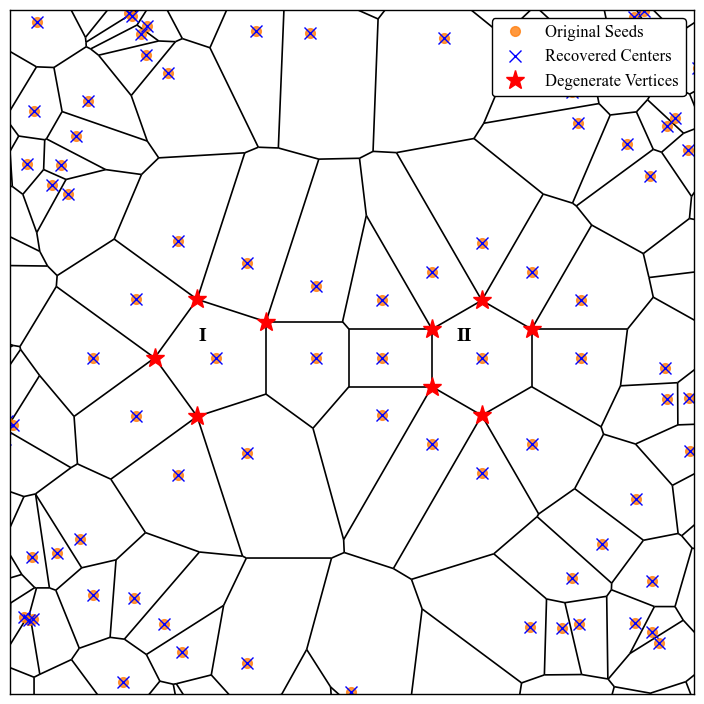

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d
import collections

# ==========================================================
# 1. Helper: Robust Circumcenter
# ==========================================================
def circumcenter(A, B, C, tol=1e-12):
    """Compute circumcenter and radius of a triangle (A,B,C)."""
    A, B, C = map(np.asarray, (A, B, C))
    d = 2.0 * np.cross(B - A, C - A)
    if abs(d) < tol:
        center = (A + B + C) / 3
        R = np.linalg.norm(center - A)
        return center, R
    a2, b2, c2 = map(lambda P: np.dot(P, P), (A, B, C))
    ux = (a2 * (B[1]-C[1]) + b2 * (C[1]-A[1]) + c2 * (A[1]-B[1])) / d
    uy = (a2 * (C[0]-B[0]) + b2 * (A[0]-C[0]) + c2 * (B[0]-A[0])) / d
    center = np.array([ux, uy])
    R = np.linalg.norm(center - A)
    return center, R

# ==========================================================
# 2. Inverse Voronoi Solver (Replaces Main_Function.py)
# ==========================================================
def fun_vor_main(vor, original_points, max_iter=500, tol=1e-12):
    """
    Iteratively recovers the original generating seeds of a Voronoi diagram 
    by reflecting neighbors across shared ridge lines.
    """
    N = len(original_points)
    neighbors = [[] for _ in range(N)]
    ridge_verts = [[] for _ in range(N)]
    
    # Map neighbors and ridges
    for (i, j), r_verts in zip(vor.ridge_points, vor.ridge_vertices):
        if -1 not in r_verts:
            neighbors[i].append(j)
            ridge_verts[i].append(r_verts)
            neighbors[j].append(i)
            ridge_verts[j].append(r_verts)
            
    cell_centers = np.zeros((N, 2))
    is_boundary = np.zeros(N, dtype=bool)
    
    # Initialize with geometric centroids for finite cells; lock boundary cells
    for i in range(N):
        region = vor.regions[vor.point_region[i]]
        if -1 in region or len(region) == 0:
            is_boundary[i] = True
            cell_centers[i] = original_points[i]
        else:
            poly = vor.vertices[region]
            cell_centers[i] = np.mean(poly, axis=0)
            
    dist_to_previous = []
    dist_to_original = []
    
    # Relaxation loop
    for step in range(max_iter):
        new_centers = np.copy(cell_centers)
        max_disp = 0.0
        
        for i in range(N):
            if is_boundary[i]:
                continue
                
            refs = []
            for j, rv in zip(neighbors[i], ridge_verts[i]):
                p0, p1 = vor.vertices[rv[0]], vor.vertices[rv[1]]
                v = p1 - p0
                denom = np.dot(v, v)
                if denom == 0: continue
                
                pj = cell_centers[j]
                t = np.dot(pj - p0, v) / denom
                f = p0 + t * v
                ref = 2 * f - pj  # Reflect point across line
                refs.append(ref)
                
            if refs:
                new_centers[i] = np.mean(refs, axis=0)
                
            disp = np.linalg.norm(new_centers[i] - cell_centers[i])
            max_disp = max(max_disp, disp)
            
        cell_centers = new_centers
        dist_to_previous.append(max_disp)
        
        rms = np.sqrt(np.mean(np.sum((cell_centers - original_points)**2, axis=1)))
        dist_to_original.append(rms)
        
        if max_disp < tol:
            print(f"            Converged after {step+1} iterations")
            break
            
    explicit_voronoi = {f'cell_{i}': {} for i in range(N)} # Mocked for compatibility
    return explicit_voronoi, vor.vertices, cell_centers, dist_to_original, dist_to_previous

# ==========================================================
# 3. Build Finite System with Annulus Padding
# ==========================================================
def build_custom_finite_degenerate_cells(cell_definitions, radius=0.3, separation=0.8, seed=42):
    """Build multiple Voronoi cells surrounded by a dense random annulus."""
    rng = np.random.default_rng(seed)
    core_points = []
    centers = []

    # Place cells along x-axis
    start_x = - (len(cell_definitions) - 1) * separation / 2.0
    
    for i, cell in enumerate(cell_definitions):
        m = cell["m"]
        n_degenerate = min(cell["n_degenerate"], m)
        center = np.array([start_x + i * separation, 0.0])
        centers.append(center)

        angles = np.linspace(0, 2 * np.pi, m, endpoint=False)
        neighbors = np.column_stack([
            center[0] + radius * np.cos(angles),
            center[1] + radius * np.sin(angles)
        ])

        D_list = []
        for k in range(n_degenerate):
            A, B, C = center, neighbors[k], neighbors[(k + 1) % m]
            circ, _ = circumcenter(A, B, C)
            D = 2 * circ - A 
            D_list.append(D)
        D = np.vstack(D_list) if len(D_list) > 0 else np.empty((0, 2))

        core_points.extend([center[None, :], neighbors, D])

    core_points = np.unique(np.round(np.vstack(core_points), 10), axis=0)

    # --- Finite Annulus Padding ---
    center_of_mass = np.mean(core_points, axis=0)
    R_core = np.max(np.linalg.norm(core_points - center_of_mass, axis=1))
    
    pad_in = R_core + 0.15
    pad_out = pad_in + 1.5
    num_pad = 600  # High density to restrict regions heavily
    
    r_pad = np.sqrt(rng.uniform(pad_in**2, pad_out**2, num_pad))
    theta_pad = rng.uniform(0, 2*np.pi, num_pad)
    pad_pts = np.column_stack([
        center_of_mass[0] + r_pad * np.cos(theta_pad),
        center_of_mass[1] + r_pad * np.sin(theta_pad)
    ])
    
    points = np.vstack([core_points, pad_pts])
    vor = Voronoi(points, qhull_options="Qbb Qc Qx")

    return vor, points, np.array(centers), R_core, center_of_mass

# ==========================================================
# 4. Main Execution & Plotting
# ==========================================================
# Define cells: "m" is edges, "n_degenerate" is forced degenerate vertices
cell_definitions = [
    {"m": 5, "n_degenerate": 4},
    {"m": 6, "n_degenerate": 5}
]

vor, pts, target_centers, R_core, com = build_custom_finite_degenerate_cells(
    cell_definitions, radius=0.3, separation=0.8
)

# Run the rebuilt Inverse Voronoi function
explicit_voronoi, vertices, cell_centers, dist_to_original, dist_to_previous = fun_vor_main(vor, pts)

# --- Identify Degenerate Vertices (Handles QHull coincidences & topology) ---
degenerate_coords = []
rounded_verts = np.round(vor.vertices, 8)
unique_verts, counts = np.unique(rounded_verts, axis=0, return_counts=True)

# 1. Catch QHull duplicates (same coordinate generated twice)
for v, count in zip(unique_verts, counts):
    if count > 1: 
        degenerate_coords.append(v)

# 2. Catch Topologically degenerate (Degree >= 4)
vertex_degrees = collections.Counter()
for simplex in vor.ridge_vertices:
    for v in simplex:
        if v != -1: vertex_degrees[v] += 1

for v, deg in vertex_degrees.items():
    if deg > 3:
        coord = rounded_verts[v]
        if not any(np.allclose(coord, dc) for dc in degenerate_coords):
            degenerate_coords.append(coord)
            
degenerate_coords = np.array(degenerate_coords)

# --- RMS Calculation ---
RMS_distance = np.sqrt(np.mean(np.sum((cell_centers - pts)**2, axis=1)))
print(f'RMS_distance between cell_centers and original points: {RMS_distance:.5e}')
print(f'log10_RMS_distance: {np.log10(RMS_distance) if RMS_distance > 0 else -np.inf:.5f}')

# --- Plotting ---
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.linewidth": 1.0,
    "axes.labelsize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "legend.frameon": False
})

fig, ax = plt.subplots(figsize=(10, 8))

# Voronoi boundaries
voronoi_plot_2d(vor, ax=ax, show_points=False, show_vertices=False, line_colors='k', line_width=1.2)

# Seeds, Recovered Centers, and Degenerate Vertices
ax.plot(pts[:,0], pts[:,1], 'o', color='tab:orange', ms=7, alpha=0.8, label="Original Seeds")
ax.plot(cell_centers[:, 0], cell_centers[:, 1], 'bx', ms=9, label="Recovered Centers")

if len(degenerate_coords) > 0:
    ax.plot(degenerate_coords[:, 0], degenerate_coords[:, 1], 'r*', markersize=14, label="Degenerate Vertices")

# Label target centers with Roman Numerals
roman_numerals = ["I", "II", "III", "IV", "V", "VI", "VII", "VIII", "IX", "X"]
for i, center in enumerate(target_centers):
    if i < len(roman_numerals):
        ax.text(center[0] - 0.03, center[1] + 0.04, roman_numerals[i], 
                color='black', fontsize=14, fontweight='bold', ha='right', va='bottom')

# Restrict the view exclusively to the core cells (+ margin) to hide the dense annulus padding
ax.set_xlim(com[0] - R_core - 0.25, com[0] + R_core + 0.25)
ax.set_ylim(com[1] - R_core - 0.25, com[1] + R_core + 0.25)
ax.set_aspect('equal')  

# Remove axes ticks and labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

# Update legend to have a white background
ax.legend(loc='upper right', frameon=True, facecolor='white', framealpha=1.0, edgecolor='black')

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig('Finite_Degenerate_Voronoi.png', dpi=600)
plt.show()